In [1]:
import torch
print(torch.cuda.is_available())

True


In [2]:
!pip install librosa tqdm

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
os.listdir("/content/drive/MyDrive")

['Colab Notebooks',
 'Seniors_Numbers.xlsx',
 'Data Analytics Free ((EXCLUSIVE)) Course With Certificate By Google.gdoc',
 'Classroom',
 'passport size pic 2 300x300.jpg',
 'sysb_nid.pdf',
 'shoishob NID front.jpeg',
 'shoishob NID back.jpeg',
 'document',
 'CSE715']

In [5]:
os.listdir("/content/drive/MyDrive/CSE715")

['GTZAN']

In [6]:
os.listdir("/content/drive/MyDrive/CSE715/GTZAN")

['Data']

In [9]:
DATA_PATH = "/content/drive/MyDrive/CSE715/GTZAN/Data/genres_original"

In [10]:
os.listdir(DATA_PATH)

['.DS_Store',
 'country',
 'hiphop',
 'rock',
 'jazz',
 'classical',
 'disco',
 'reggae',
 'blues',
 'metal',
 'pop']

In [12]:
import librosa
import numpy as np
import os
from tqdm import tqdm
import matplotlib.pyplot as plt

In [13]:
def extract_mfcc(file_path):
    y, sr = librosa.load(file_path, duration=30)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    return np.mean(mfcc.T, axis=0)

In [15]:
X = []
y = []

for genre in os.listdir(DATA_PATH):

    genre_path = os.path.join(DATA_PATH, genre)

    # ✅ skip non-directories (.DS_Store etc.)
    if not os.path.isdir(genre_path):
        continue

    for file in tqdm(os.listdir(genre_path)):
        file_path = os.path.join(genre_path, file)

        try:
            mfcc = extract_mfcc(file_path)
            X.append(mfcc)
            y.append(genre)
        except:
            pass

X = np.array(X)

 51%|█████▏    | 52/101 [00:07<00:04, 10.26it/s]/tmp/ipykernel_560/503129895.py:2: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, duration=30)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
100%|██████████| 100/100 [00:11<00:00,  8.54it/s]


In [16]:
X.shape

(1000, 40)

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [18]:
X_scaled[:2]

array([[ 1.3631965 , -1.1760701 ,  0.34450656, -0.49219185,  0.9111621 ,
        -0.44741094,  1.0626385 , -0.02944194,  1.2120461 ,  0.08721845,
         0.9303211 ,  0.30754244,  0.89828473, -0.71099997,  0.9707983 ,
         0.40002552,  0.26401147,  0.5982468 ,  0.15578757,  0.5388556 ,
         0.21636362, -1.0766402 , -0.5055392 ,  0.03354941, -0.7702123 ,
         0.63828224,  0.31588134, -0.26082873, -0.08721427,  0.26220775,
        -2.2259936 , -1.6053209 , -1.5128615 , -0.23056103, -0.10130873,
        -0.60791296, -0.20359622, -0.10031717, -0.8396651 ,  0.18371712],
       [ 1.2117177 , -0.93555915,  0.5878968 , -0.47939014,  1.2215676 ,
        -0.7539984 ,  0.9176146 , -0.25638875,  1.1663147 ,  0.09581425,
         0.5491388 , -0.35753477,  0.23085006,  0.66619265,  0.759947  ,
        -0.17317645,  1.0007861 ,  0.9099198 ,  0.8665438 ,  1.3514391 ,
        -0.23264961, -0.05581791, -0.6167249 ,  0.5852062 ,  0.33582518,
         1.6642812 , -0.26279923,  0.40009472,  0.

In [19]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device)

print(device)

cuda


In [20]:
import torch.nn as nn

In [21]:
class VAE(nn.Module):

    def __init__(self, input_dim=40, latent_dim=8):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU()
        )

        # Latent parameters
        self.mu = nn.Linear(32, latent_dim)
        self.logvar = nn.Linear(32, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)
        mu = self.mu(h)
        logvar = self.logvar(h)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar

In [22]:
model = VAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [23]:
def loss_fn(recon, x, mu, logvar):

    recon_loss = ((recon - x) ** 2).mean()

    kl_loss = -0.5 * torch.mean(
        1 + logvar - mu**2 - logvar.exp()
    )

    return recon_loss + kl_loss

In [24]:
for epoch in range(50):

    optimizer.zero_grad()

    recon, mu, logvar = model(X_tensor)

    loss = loss_fn(recon, X_tensor, mu, logvar)

    loss.backward()
    optimizer.step()

    print("Epoch:", epoch, "Loss:", loss.item())

Epoch: 0 Loss: 1.0253586769104004
Epoch: 1 Loss: 1.0232062339782715
Epoch: 2 Loss: 1.0205013751983643
Epoch: 3 Loss: 1.016884684562683
Epoch: 4 Loss: 1.0154353380203247
Epoch: 5 Loss: 1.0138767957687378
Epoch: 6 Loss: 1.0123018026351929
Epoch: 7 Loss: 1.0106407403945923
Epoch: 8 Loss: 1.0093436241149902
Epoch: 9 Loss: 1.0088146924972534
Epoch: 10 Loss: 1.0062681436538696
Epoch: 11 Loss: 1.007344126701355
Epoch: 12 Loss: 1.0072956085205078
Epoch: 13 Loss: 1.0049550533294678
Epoch: 14 Loss: 1.005458116531372
Epoch: 15 Loss: 1.0055277347564697
Epoch: 16 Loss: 1.0056437253952026
Epoch: 17 Loss: 1.00411856174469
Epoch: 18 Loss: 1.0036780834197998
Epoch: 19 Loss: 1.0039772987365723
Epoch: 20 Loss: 1.00344717502594
Epoch: 21 Loss: 1.0036139488220215
Epoch: 22 Loss: 1.0029689073562622
Epoch: 23 Loss: 1.0030919313430786
Epoch: 24 Loss: 1.0032275915145874
Epoch: 25 Loss: 1.0021876096725464
Epoch: 26 Loss: 1.002394676208496
Epoch: 27 Loss: 1.002622127532959
Epoch: 28 Loss: 1.0027955770492554
Epoc

In [25]:
with torch.no_grad():
    h = model.encoder(X_tensor)
    z = model.mu(h).cpu().numpy()

z.shape

(1000, 8)

In [26]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=10, random_state=42)
labels = kmeans.fit_predict(z)

In [27]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score

sil = silhouette_score(z, labels)
ch = calinski_harabasz_score(z, labels)

print("Silhouette Score:", sil)
print("Calinski-Harabasz:", ch)

Silhouette Score: 0.113637224
Calinski-Harabasz: 146.77986


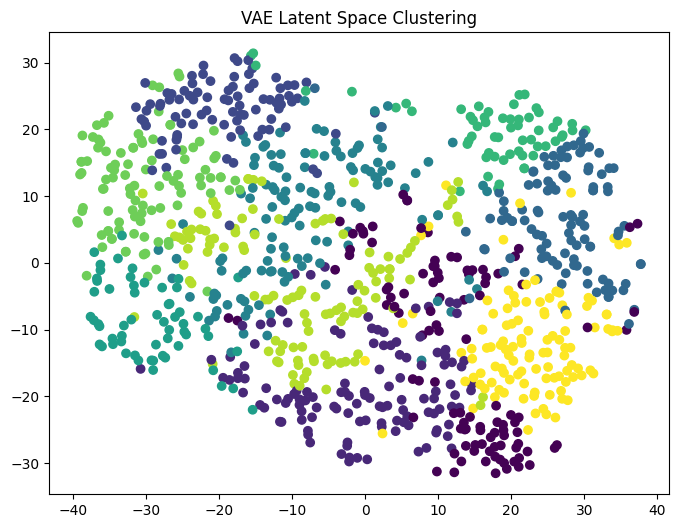

In [28]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

z_2d = TSNE(n_components=2, random_state=42).fit_transform(z)

plt.figure(figsize=(8,6))
plt.scatter(z_2d[:,0], z_2d[:,1], c=labels)
plt.title("VAE Latent Space Clustering")
plt.show()